In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats

from functools import reduce

from patsy import dmatrices
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_blobs

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

## Preprocessing
### Merging Datasets
We merge all three datasets by extracting all US-based S&P 500 companies appearing in the datasets containing employee satisfaction ratings, ESG risk scores, and current stock market information. An outer join is performed between these three datasets based on their ticker symbol.

In [7]:
# File-paths
empl_revs_path = 'employeeratings.csv'
esg_risk_path  = 'esgrisk.csv'
fin_perf_path = 'sp500_companies.csv'

# Create dataframes
empl_revs_df = pd.read_csv(empl_revs_path)
esg_risk_df = pd.read_csv(esg_risk_path)
fin_perf_df = pd.read_csv(fin_perf_path)

# Minor preprocessing to ease merge
empl_revs_df = empl_revs_df.rename(columns={'4951': 'Symbol'})
fin_perf_df = fin_perf_df.drop(['Industry'], axis=1)

# Ticker symbosl per company
empl_symbols = empl_revs_df['Symbol'].values
esg_symbols  = esg_risk_df['Symbol'].values
fin_symbols = fin_perf_df['Symbol'].values

# Use ticker symbols that appear in all three dataframes as a join
join_symbols = [ticker for ticker in empl_symbols if ticker in esg_symbols if ticker in fin_symbols]

# Use join as masks to extract all US-based S&P 500 comapnies that have pertinent data
esg_filter = esg_risk_df['Symbol'].isin(join_symbols)
fin_filter = fin_perf_df['Symbol'].isin(join_symbols)
esg_risk_df = esg_risk_df[esg_filter]
fin_perf_df = fin_perf_df[fin_filter]
dfs = [empl_revs_df, esg_risk_df, fin_perf_df]

# Raw data of merged employee, ESG, financial dataframe via outer join
EEF_df = reduce(lambda l,r: pd.merge(l, r, on='Symbol', how='outer'), dfs)

# Renaming & reordering columns of joined dataframe, then dropping rows with null values
# Note: features commented out for potential further use/future applications
columns_rename = {
    'Industry_x': 'Industry',
    'Industry-Sub': 'Subindustry',
    'Glassdoor Overall Star Rating (out of 5)': 'Glassdoor Rating',
    'Indeed Overall Star Rating (out of 5)': 'Indeed Rating',
    'Comparably Overall Star Rating': 'Comparably Rating',
    'Total ESG Risk score': 'Total ESG Risk Score',
    'Ebitda': 'EBITDA',
    'Marketcap': 'Market Capitalization'
}
columns = [
    'Symbol',
    'Company',
    'Industry',
    'Subindustry',
    'Glassdoor Rating',
    #'Glassdoor Reviews Total',
    'Indeed Rating',
    #'Indeed Reviews Total',
    'Comparably Rating',
    #'Comparably Reviews Total',
    'Environment Risk Score',
    'Social Risk Score',
    'Governance Risk Score',
    'Total ESG Risk Score',
    'Controversy Score',
    'Full Time Employees',
    'EBITDA',
    'Market Capitalization'
]
EEF_df = EEF_df.rename(columns=columns_rename)
EEF_df = EEF_df[columns]

### Standardization & Verification
To ease data analysis ahead, we first drop all rows in the joined dataset.

A helper function is used to standardize features containing strings that represent numerical quantities and convert its datatype to float64. 

A new feature containing average employee satisfaction ratings across all three initial sources is created and inserted into the dataframe, before validating and verifying the datatypes of all numerical features. 

In [8]:
# Helper function that standardizes string entries into numerical quantities
def standardize_num(entry):
    if type(entry) != type('str'):
        output = entry
    else:
        string = entry
        string = string.strip()
        string = string.replace(',', '')
    
        if string.isnumeric():
            output = int(string)
        else:
            output = np.nan
        
    return output

In [9]:
# Drop companies containing missing data
EEF_df = EEF_df.dropna()

# Standardize full time employees
EEF_df['Full Time Employees'] = EEF_df['Full Time Employees'].apply(standardize_num)
astype = {'Full Time Employees': 'float64'}
EEF_df = EEF_df.astype(astype)

# Insert average employee satisfaction rating as a new feature
EEF_df.insert(7, 'Mean Ratings', EEF_df[['Glassdoor Rating','Indeed Rating','Comparably Rating']].mean(axis=1))

# Verify that all features are of the appropriate datatype
EEF_df.dtypes

Symbol                     object
Company                    object
Industry                   object
Subindustry                object
Glassdoor Rating          float64
Indeed Rating             float64
Comparably Rating         float64
Mean Ratings              float64
Environment Risk Score    float64
Social Risk Score         float64
Governance Risk Score     float64
Total ESG Risk Score      float64
Controversy Score         float64
Full Time Employees       float64
EBITDA                    float64
Market Capitalization     float64
dtype: object

### Variable Descriptions
- Symbol (str): 
Stock/ticker symbol
- Company (str): Company name
- Industry (str): Industry of company operations
- Subindustry (str): Subindustry within industry of company operations (string)
- Glassdoor Rating (float): Overall employee satisfaction rating found in Glassdoor 
- Indeed Rating (float): Overall employee satisfaction rating found in Indeed 
- Comparably Rating (float): Overall employee satisfaction rating found in Comparably
- Mean Ratings (float): Average of all three employee satisfaction ratings 
- Full Time Employees (float): Number of people in the company employed full time 
- Environment Risk Score (float)
- Social Risk Score (float)
- Gvernance Risk Score (float)
- Total ESG Risk Score (float)
- Controversy Score (float)
- EBITDA (float): Earnings before interest, taxes, depreciation, & amortization 
- Market Capitalization (float): Market capitalization (float)

# Exploratory Data Analysis
We're seeking to explore the relationship between a company's employee satisfaction rating, ESG rating, & overall financial value, and so constructing a multivariate linear regression model with these varying metrics as predictors would be suited towards assessing our hypothesis. 

Background research strongly indicates that a company's operational capacity and performance is strongly tied to the intersection between these various relationships, so it is incorporated into the dataset and quantified by both the number of people employed full time at tha company and the company's current EBITDA. 

Given that we're interested in a company's financial worth, in addition to their potential future performance and valuation, a company's current market capitalization is best suited as the response variable in the model. 

After further processing the raw numerical quantities from the joined dataset, we initially check the statistics of each variable in the model. 

In [10]:
# Rename columns for ease of use in numerical & statistical analysis, & store
# the raw numerical values in Ratings, Risk, Capital dataframe for analysis;
# drop individual ratings & have it represented by the average ratings feature
features = EEF_df.describe().columns[-9:]
RRC_stats = EEF_df.describe()[features]
RRC_stats.columns = [
    'mean_ratings',
    'env_risk',
    'soc_risk',
    'gov_risk',
    'esg_risk',
    'controversy_score',
    'full_time_employees',
    'ebitda',
    'market_cap'
]

# Check statistics of all numerical features in the dataset
RRC_stats

,mean_ratings,env_risk,soc_risk,gov_risk,esg_risk,controversy_score,full_time_employees,ebitda,market_cap
count,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,1.430000e+02,1.430000e+02,1.430000e+02
mean,3.815152,4.937063,8.601399,5.872727,19.454545,1.993007,1.084339e+05,9.565515e+09,1.670573e+11
std,0.358110,4.048242,3.384991,1.704723,6.571093,0.953101,2.374504e+05,1.960510e+10,4.353917e+11
min,2.766667,0.000000,2.000000,3.200000,7.000000,0.000000,9.140000e+02,3.610000e+08,5.917852e+09
25%,3.600000,1.850000,6.500000,4.700000,14.000000,2.000000,1.495000e+04,1.669100e+09,1.926199e+10
50%,3.866667,4.000000,8.000000,5.500000,18.000000,2.000000,3.700000e+04,3.417000e+09,4.059013e+10
75%,4.100000,7.500000,10.850000,6.800000,24.000000,3.000000,1.013500e+05,7.289475e+09,1.208876e+11
max,4.500000,18.000000,21.000000,11.400000,37.000000,4.000000,2.100000e+06,1.301090e+11,3.005761e+12


In [11]:
# New dataframe extracting only numerical features in numerical processing
RRC_df = EEF_df[features]
RRC_df.columns = RRC_stats.columns

Text(0, 0.5, 'Frequency')

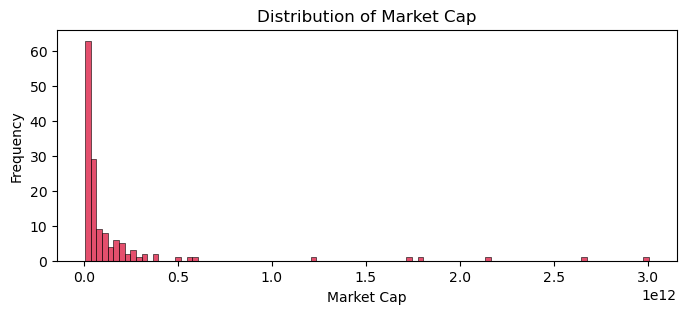

In [12]:
# Histogram of response variable
plt.figure(figsize=(8,3))
sns.histplot(RRC_df['market_cap'], bins=100, color='crimson')
plt.title('Distribution of Market Cap')
plt.xlabel('Market Cap')
plt.ylabel('Frequency')

From the numerical description of the dataset's statistics and the histogram of the response variable, we can observe that the distribution of market cap is strongly right-skewed and has a long tail, i.e. folllows a power law and exponentially distributed. Rescaling the response variable will help assess how each predictor's relationship with the response variable is distributed.

In [13]:
# logarithmically scaling the response variable to reshape distribution
RRC_df.loc[:,'market_cap'] = np.log(RRC_df['market_cap'].values)
RRC_df = RRC_df.rename(columns={'market_cap': 'ln_marketcap'})

C:\Users\lmtua\AppData\Local\Temp\ipykernel_18556\3344896089.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  RRC_df.loc[:,'market_cap'] = np.log(RRC_df['market_cap'].values)


## Testing for Linearity
The relationship between predictors (independent variables) and the response variable is required to be linear. The pairplot below generates the scatter plots between all predictors and market cap, allowing us to assess the linearity assumption visually in addition to checking the distributions of each predictor as well.

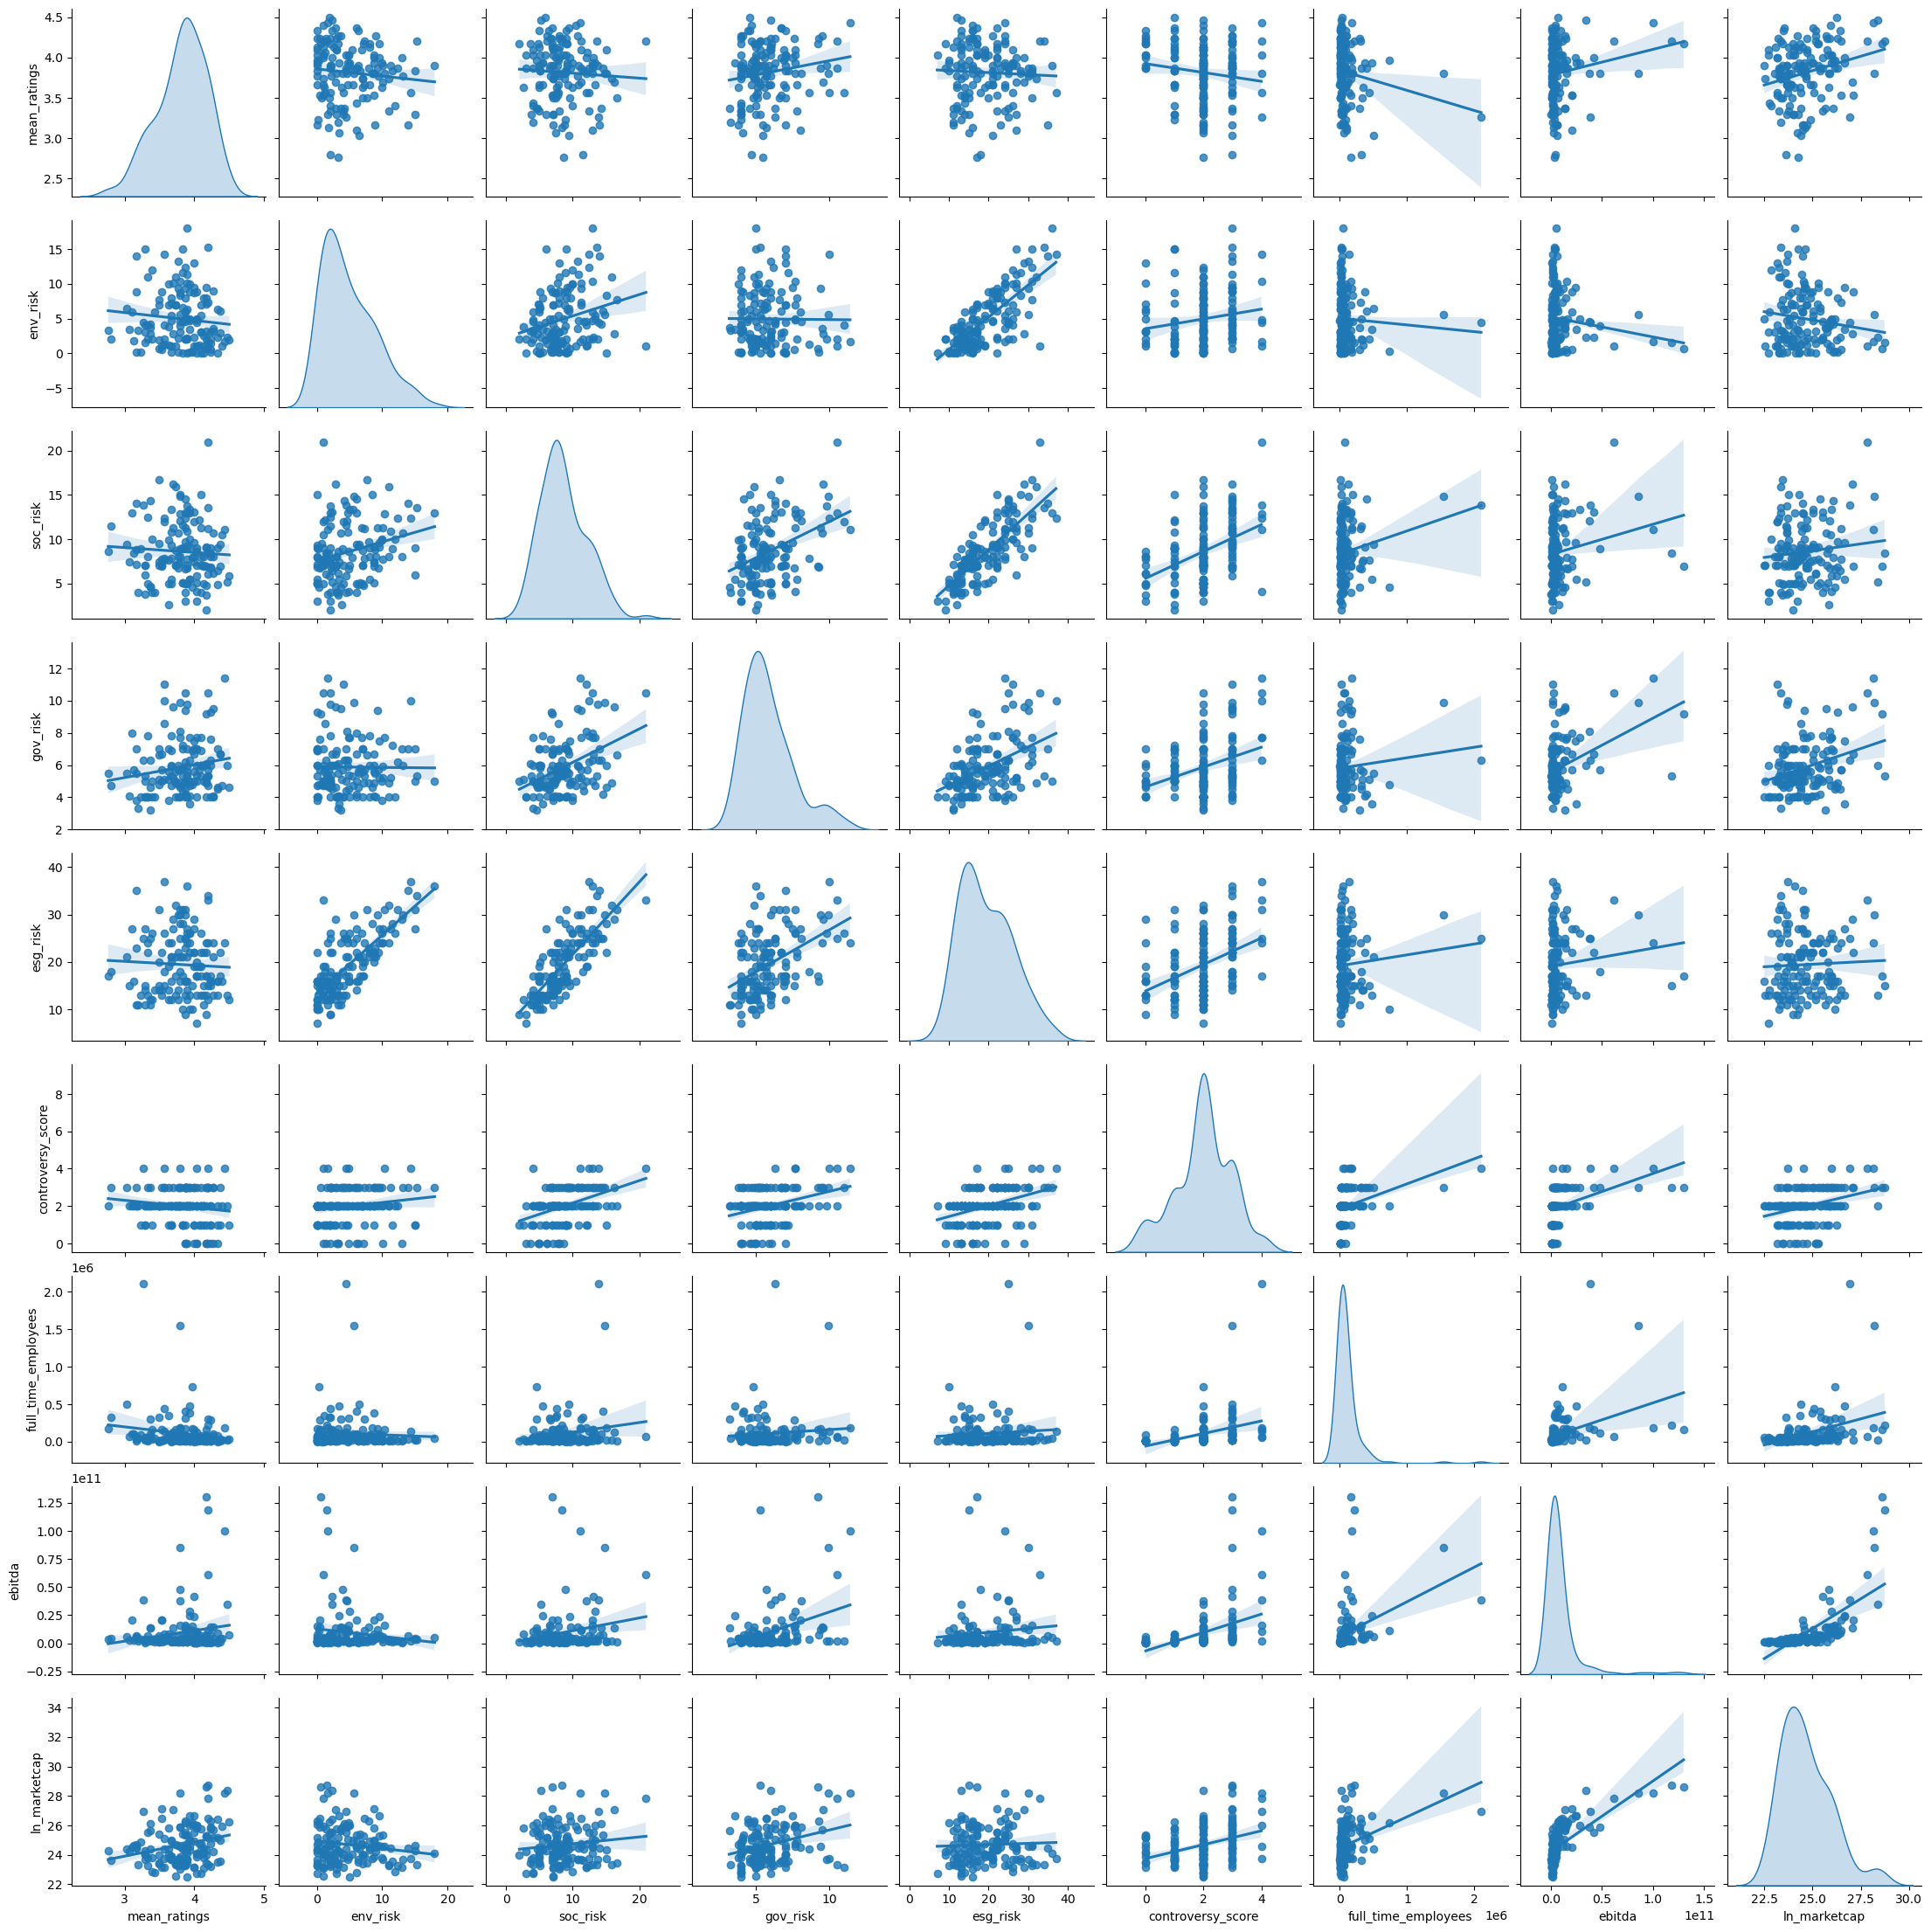

In [14]:
# Pairplot to visualize distributions (kde);
# toggled kind=regression in order to assess linearity
sns.pairplot(data=RRC_df, kind='reg', diag_kind='kde')

We can see that market cap is less skewed after its logarithmic scaling and that all predictors, while not ideal, have a somewhat linear relationship with market cap, albeit with high variance. 

In addition, the predictors representing operational capacity & performance are also similarly distributed to the original exponential distribution of market cap and can be rectified with a similar nonlinear scaling. 

In [15]:
# Logarithmic rescaling of full time employees & EBITDA
exp_dist = ['full_time_employees', 'ebitda']
RRC_df.loc[:,exp_dist] = np.log(RRC_df.loc[:,exp_dist].values)

# columns are renamed in order to signify that the feature has been scaled
# & is important when interpreting the model coefficients in regression analysis
RRC_df = RRC_df.rename(columns={'full_time_employees': 'ln_fulltime', 'ebitda': 'ln_ebitda'})

## Testing for Multicollinearity
Linear regression models assume no multicollinearity. Multicollinearity is present in the data when some of the predictors in the model are highly correlated with eac other. This can be tested in two ways: plotting a heatmap for the data's Pearson correlation matrix and calculating the variance inflation factor (VIF) of the linear regression. 

A VIF equal to 1 indicates zero correlation between a given predictor and other predictors in the model. If a predictor's VIF is between 1 and 5, while it indicates some moderate correlation, it does not pose a problem for the model. A VIF greater than 5 for a predictor indicates a severe correlation with other predictors, indicating multicollinearity in the data.

In [16]:
# Helper function tests multicollinearity by calculating variance inflation factors for each 
# predictor with respect to other predictors; if heat boolean is flagged, it plots a heatmap
# visually representing the Pearson correlation matrix of the dataset
def test_multicollinearity(regression_eqn, data, **kwargs):
    heat = kwargs.get('heat')
    
    data = data.copy(deep=True)
    
    # plot heatmap correlation matrix if flagged
    if heat == True:
        plt.figure(figsize=(14,6))
        corr_heatmap = sns.heatmap(
            data = data.corr(), 
            vmin = -1,
            vmax = 1,
            center = 0,
            cmap = 'RdGy',
            annot = True,
            fmt = '.2f',
            linewidth = 0.5
        )
        corr_heatmap.set_title(label = 'Correlation Heatmap', fontdict = {'fontsize':20}, pad=12)
    
    # design matrices for regression model using market cap as response variable
    y_design, X_design = dmatrices(regression_eqn, data=data, return_type='dataframe')
    
    # create DataFrames to hold VIF values
    vif_df = pd.DataFrame()
    vif_df['predictor'] = X_design.columns
    
    # calculate VIFs for predictors
    vif_df['VIF'] = [variance_inflation_factor(X_design.values,index) for index in range(X_design.shape[1])]
    
    # view VIF per predictor 
    print('VIFs for every predictor in multivariate regression equation:')
    print(regression_eqn + '\n')
    print(vif_df)
    
    return vif_df

VIFs for every predictor in multivariate regression equation:
ln_marketcap ~ mean_ratings + env_risk + soc_risk + gov_risk + esg_risk + controversy_score + ln_fulltime + ln_ebitda

           predictor         VIF
0          Intercept  537.148606
1       mean_ratings    1.209785
2           env_risk  119.617145
3           soc_risk   85.919213
4           gov_risk   20.605510
5           esg_risk  304.255931
6  controversy_score    2.030675
7        ln_fulltime    2.067226
8          ln_ebitda    2.264624


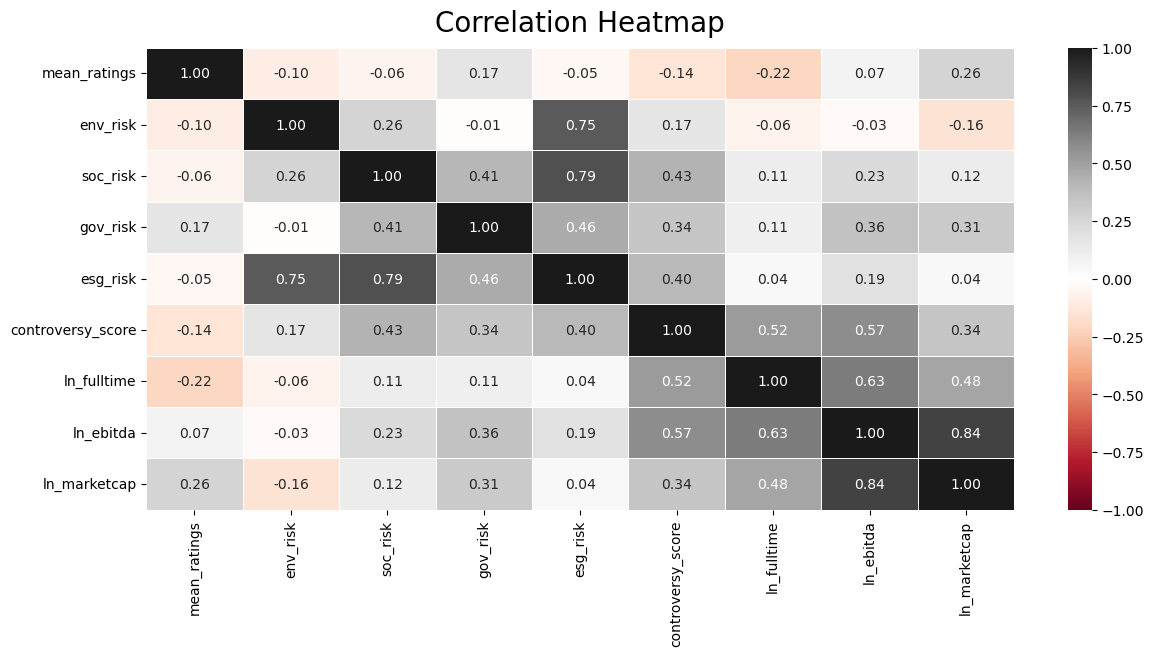

In [17]:
regr_equation = 'ln_marketcap ~ mean_ratings + env_risk + soc_risk + gov_risk + esg_risk + controversy_score + ln_fulltime + ln_ebitda'
_ = test_multicollinearity(regr_equation, RRC_df, heat=True)

The following observations can be made from both the VIF calculations and the heatmap above:
- All predictors that quantify ESG risk scores are far too highly correlated with each other, likely due to the total ESG risk score being a direct lienar combination of the prior three, and so this can be rectified by dropping it as a predictor; this is favorable since we want to preserve which aspects of ESG initiatives impact a company's value and performance when they pursue and implement them.
- The (log-transformed) metrics of numer of full time employees and EBITDA are also hihgly correlated with each other and since both are of high interest, this can be resolved by performing the regression with two separate predictors for operating capacity/performance, one with (log) full time employees & the other with (log) EBITDA.

In [18]:
def regression_eq(op_capacity):
    eq = 'ln_marketcap ~ mean_ratings + env_risk + soc_risk + gov_risk '
    eq = eq + '+ controversy_score + ' + op_capacity
    
    return eq

In [19]:
# drop total esg risk score as a feature in the model
RRC_df = RRC_df.drop('esg_risk', axis=1)

ln_ebitda_eq = regression_eq('ln_ebitda')
_ = test_multicollinearity(ln_ebitda_eq, RRC_df)

VIFs for every predictor in multivariate regression equation:
ln_marketcap ~ mean_ratings + env_risk + soc_risk + gov_risk + controversy_score + ln_ebitda

           predictor         VIF
0          Intercept  535.724630
1       mean_ratings    1.110623
2           env_risk    1.117196
3           soc_risk    1.453043
4           gov_risk    1.405810
5  controversy_score    1.860201
6          ln_ebitda    1.624437


In [20]:
ln_fulltime_eq = regression_eq('ln_fulltime')
_ = test_multicollinearity(ln_fulltime_eq, RRC_df)

VIFs for every predictor in multivariate regression equation:
ln_marketcap ~ mean_ratings + env_risk + soc_risk + gov_risk + controversy_score + ln_fulltime

           predictor         VIF
0          Intercept  250.382588
1       mean_ratings    1.122465
2           env_risk    1.135859
3           soc_risk    1.460127
4           gov_risk    1.364502
5  controversy_score    1.808661
6        ln_fulltime    1.480023


We can see that in both models, the VIF for every predictor is relatively close to 1, and so multicollinearity will not be an issue in the regression model provided the above constraints hold. 

### Testing for Multivariate Normality
Linear regression also assumes that each predictor is multivariate normal, i.e. all variables in the model follow a normal distribution. From the pairplot generated above, we can see that most of the feature distributions fail this assumption. So we standardize our features with a z-score scaler, which rescales the feature values to have a mean of 0 and a standard deviation of 1. 

We can then verify multivariate normality for each predictor by using Q-Q plots. If the  predictor does indeed follow a normal distribution, then the datapoints in the Q-Q plots should fall within range of the 45 degree line, as shown below.

QQ plot for mean_ratings


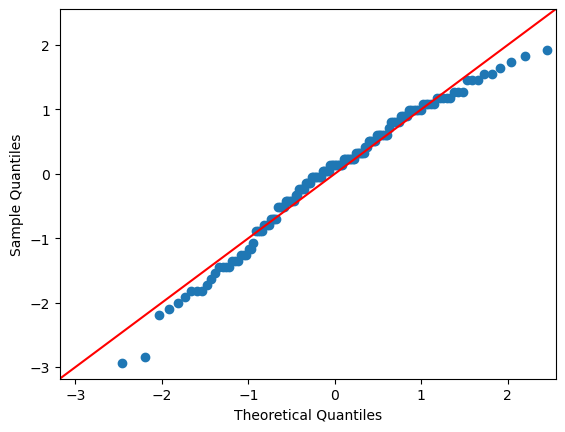

QQ plot for env_risk


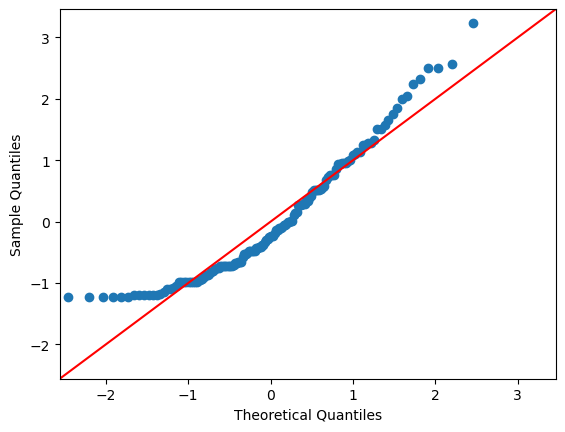

QQ plot for soc_risk


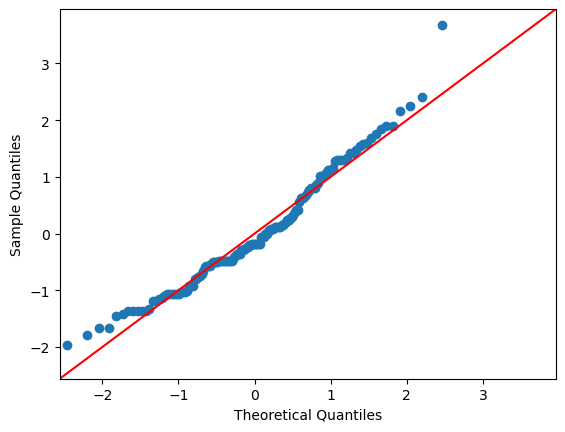

QQ plot for gov_risk


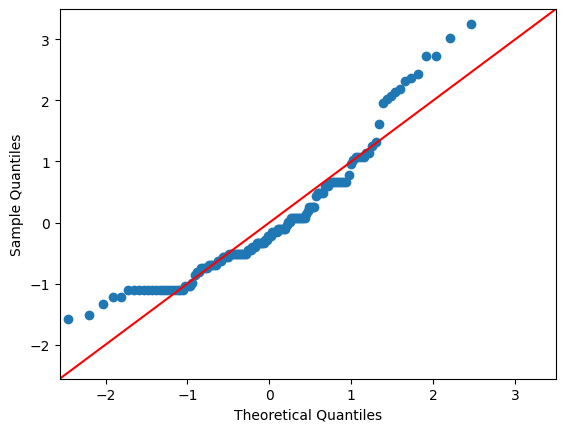

QQ plot for controversy_score


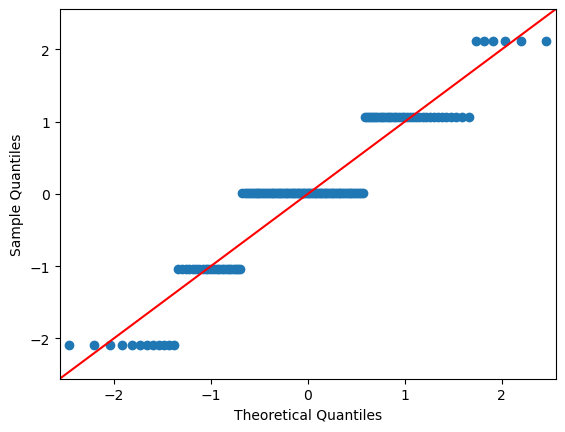

QQ plot for ln_fulltime


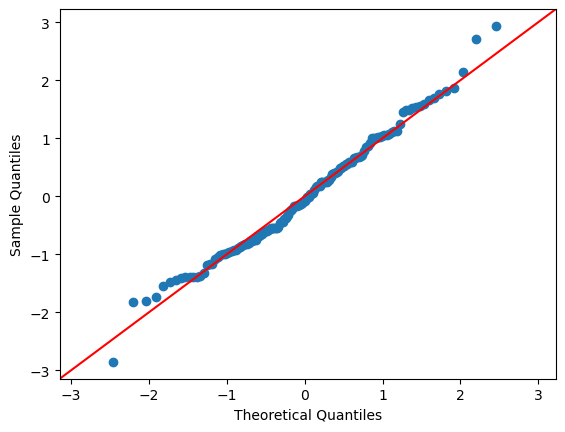

QQ plot for ln_ebitda


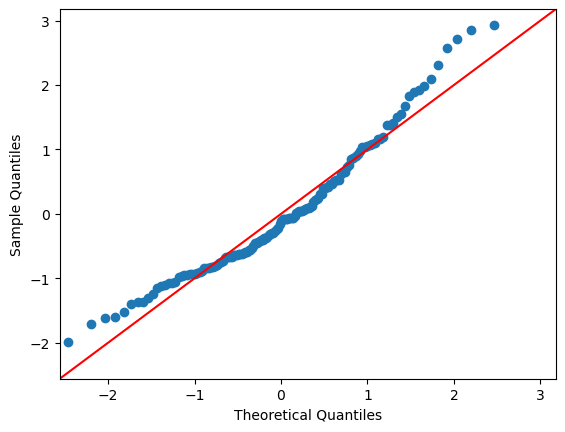

QQ plot for ln_marketcap


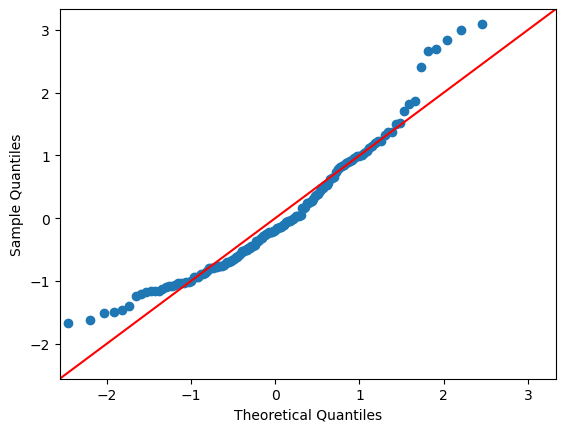

In [21]:
# copy dataframe in order to preserve unscaled features
EDA_df = RRC_df.copy(deep=True)

# define scalers, then fit and transform the features
standardize = StandardScaler()
standard = standardize.fit_transform(EDA_df)
EDA_df = pd.DataFrame(standard, columns=EDA_df.columns)

# generate QQ plots with 45 degree line added to plot
for pred in EDA_df.columns:
    print('QQ plot for ' + pred)
    fig = sm.qqplot(EDA_df.loc[:,pred], line='45')
    plt.show()

While some features are moderately skewed, we can see overall that each predictor has a relatively Gaussian distribution after standardization the values. This can be seen in the numerical description of the dataframe's statistics below. Note the mean and standard deviation for all predictors.

In [22]:
EDA_df.describe()

,mean_ratings,env_risk,soc_risk,gov_risk,controversy_score,ln_fulltime,ln_ebitda,ln_marketcap
count,1.430000e+02,1.430000e+02,1.430000e+02,1.430000e+02,1.430000e+02,1.430000e+02,1.430000e+02,1.430000e+02
mean,1.826045e-15,1.180097e-16,-8.695453e-17,3.369488e-16,1.234444e-16,-2.422305e-16,-2.189391e-15,-7.919073e-16
std,1.003515e+00,1.003515e+00,1.003515e+00,1.003515e+00,1.003515e+00,1.003515e+00,1.003515e+00,1.003515e+00
min,-2.938118e+00,-1.223844e+00,-1.957051e+00,-1.573347e+00,-2.098426e+00,-2.857490e+00,-1.986454e+00,-1.665717e+00
25%,-6.029085e-01,-7.652491e-01,-6.229809e-01,-6.903462e-01,7.362900e-03,-7.652028e-01,-7.076070e-01,-7.642407e-01
50%,1.443584e-01,-2.322877e-01,-1.782907e-01,-2.194124e-01,7.362900e-03,-8.673876e-02,-1.088915e-01,-1.948638e-01
75%,7.982169e-01,6.353241e-01,6.666206e-01,5.458551e-01,1.060258e+00,6.676744e-01,5.240221e-01,6.387280e-01
max,1.919117e+00,3.238159e+00,3.675691e+00,3.253725e+00,2.113152e+00,2.937016e+00,2.931451e+00,3.093375e+00


We now perform OLS regression on both models we have generated above. 

Note that testing for the final two linear regression assumptions, homoscedasticity and no autocorrelation (the residuals are uniformly distributed and not linearly autocorrelated as in a time series, respectively), can easily be assessed after performing the regression and checking the summary of statistics afterwards. 

In [23]:
# Helper function that performs OLS in order to fit the regression line to the data as
# defined by the model, a summary is printed, and all coefficients of a particular
# statistical significance as evaluated by their p-value is extracted from the
# data while everything else is dropped
def ret_reg_res(regression_eq, data, threshold):
    response = regression_eq.split()[0]
    
    # design matrices to perform Ordinary Least Squares to calculate model fit
    y, X = dmatrices(regression_eq, data=data.copy(deep=True), return_type='dataframe')
    model = sm.OLS(y,X)
    results = model.fit()
    print(results.summary())
    
    index = results.params.index
    columns = ['coef', 'pval']
    coef_df = pd.DataFrame(
        data = zip(results.params.values, results.pvalues.values), 
        index = results.params.index, 
        columns = ['coef', 'pval']
    )
    
    # mask to filter out significant regression coefficients
    significant = coef_df['pval'] < threshold
    coef_df = coef_df[significant]
    
    print('\n====================================================')
    print('Multivariate Linear Model Coefficients: ' + response)
    print('----------------------------------------------------')
    print('                             threshold (alpha): ' + str(threshold))
    print('----------------------------------------------------')
    for coef in coef_df.index:
        print(coef + ': ' + str(coef_df.loc[coef,'coef']))
    print('====================================================\n\n')
    
    return coef_df.index.values

In [24]:
# threshhold for assessing statistical significance of model coefficients
alpha = 0.05

ln_ebitda_coef = ret_reg_res(ln_ebitda_eq, EDA_df, alpha)
ln_fulltime_coef = ret_reg_res(ln_fulltime_eq, EDA_df, alpha)

                            OLS Regression Results                            
Dep. Variable:           ln_marketcap   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.765
Method:                 Least Squares   F-statistic:                     78.24
Date:                Sat, 17 Aug 2024   Prob (F-statistic):           1.16e-41
Time:                        13:44:59   Log-Likelihood:                -96.138
No. Observations:                 143   AIC:                             206.3
Df Residuals:                     136   BIC:                             227.0
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -9.021e-16      0.04

From the Durbin-Watson d values from the statistics summary of each model are close to 2, indicating no autocorrelation in the residuals. While d can assume any value in the interval [0, 4], it is generally accepted that if d lies within (1.5,2.5), there is little to no linear autocorrelation in the residuals, hence satisfying the fourth linear regression assumption. 

We can see from the first model with (lng) EBITDA as the feature representing operating capacity that the mean employee satisfaction ratings, environmental risk score, controversy score, and (log) EBITDA are statistically significant features in the model when predicting for (log) market cap.

On the other hand, interestingly enough, from the second model with (log) number of full time employees as the operational performance feature, only the mean employee satisfaction ratings, governance risk score, and (log) number of full time employees were found to be statistically significant features when predicting for (log) market cap.

However, we can see from the R-squared values or coefficients of determination that the first model does not predict the response variable well, with an R2 of 0.775 & the second model performing slightly better but with R2 of 0.424. This is in spite of the standard error being relatively low for each predictor in both models.

### Testing for Homoscedasticity
Now that we have the coefficients for the fitted model, we can test for homoscedasticity by plotting the predicted values against the residuals (the difference between the observed values and the predicted values). If the data is homoscedastic, then the residuals do not have uniform variability and the model has to be revisited. If the model is heteroscedastic, then the scatter plot should have a random and even distribution across the horizontal axis. 

In [25]:
def get_regressor(data, coefs, response):
    X = data[coefs]
    y = data[response]
    
    model = LinearRegression()
    regressor = model.fit(X,y)
    
    return regressor

In [26]:
def make_predictions(data, coefs, response):
        
    regressor = get_regressor(data, coefs, response)
    beta = regressor.coef_
    
    X = data[coefs].values
    yhat = beta @ X.T
    
    return yhat

In [27]:
def plot_model_residuals(data, coefs, response, **kwargs):
    version = kwargs.get('version')
    
    data = data.copy(deep=True)
    
    y = data[response].values
    yhat = make_predictions(data, coefs, response)
    
    residuals = y-yhat
    
    op_coef = coefs[-1:]
    
    plt.figure(figsize=(14,8))
    
    if version == 'homoscedastic':
        plt.scatter(yhat, residuals, color='gray', s=6, alpha=0.7)
        plt.axhline(y=0, color='crimson', linestyle='-', linewidth=0.6)
        plt.title('Predicted w/ ' + op_coef + ' in model predicting ' + response + ' vs Residuals')
        plt.xlabel('predicted')
        plt.ylabel('residual')
    else:
        plt.scatter(yhat, y, color='gray', s=6, alpha=0.7)
        plt.axline((0, 0), (1, 1), color='crimson', linestyle='-', linewidth=0.6)
        plt.title('Predicted ' + response + ' vs. Actual ' + response)
        plt.xlabel('predicted')
        plt.ylabel('actual')

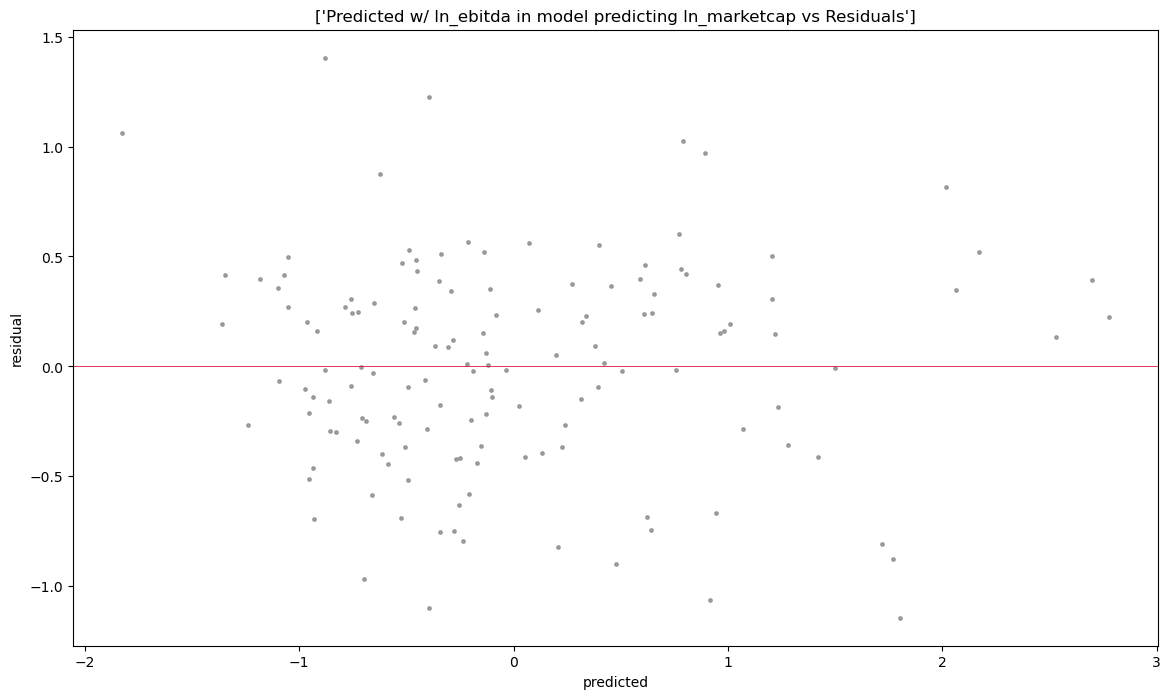

In [28]:
plot_model_residuals(EDA_df, ln_ebitda_coef, response='ln_marketcap', version='homoscedastic')

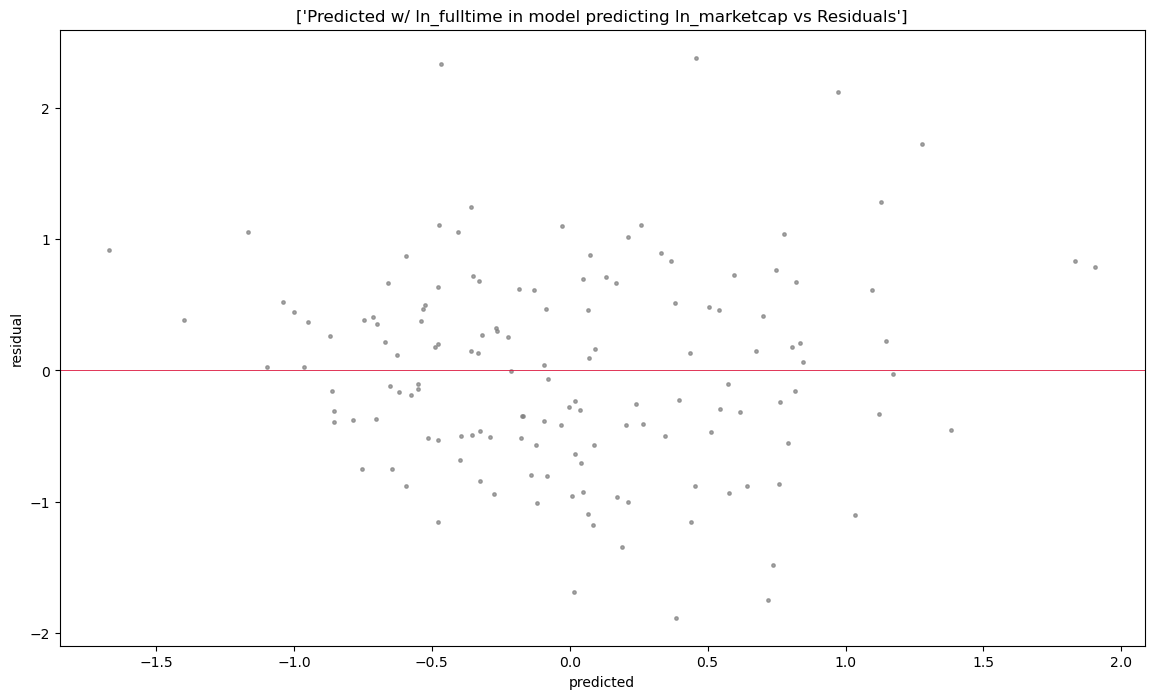

In [29]:
plot_model_residuals(EDA_df, ln_fulltime_coef, response='ln_marketcap', version='homoscedastic')

As we can see from the scatter plots above, the model using (log) number of full time employees as the quantifier for operational capacity and performance is more heteroscedastic than the model using (log) EBITDA. This is in agreement with the R2 scores of the OLS results. From here we can safely discard the model using (log) EBITDA as the operational capacity predictor for (log) market cap. For further verification of the residuals in the model using (log) number of full time employees, we plot hte predicted values against the actual values in a scatter plot. The error would be determiend by their variance and whether the datapoints of the scatter plot follow the 45 degree line shown below.

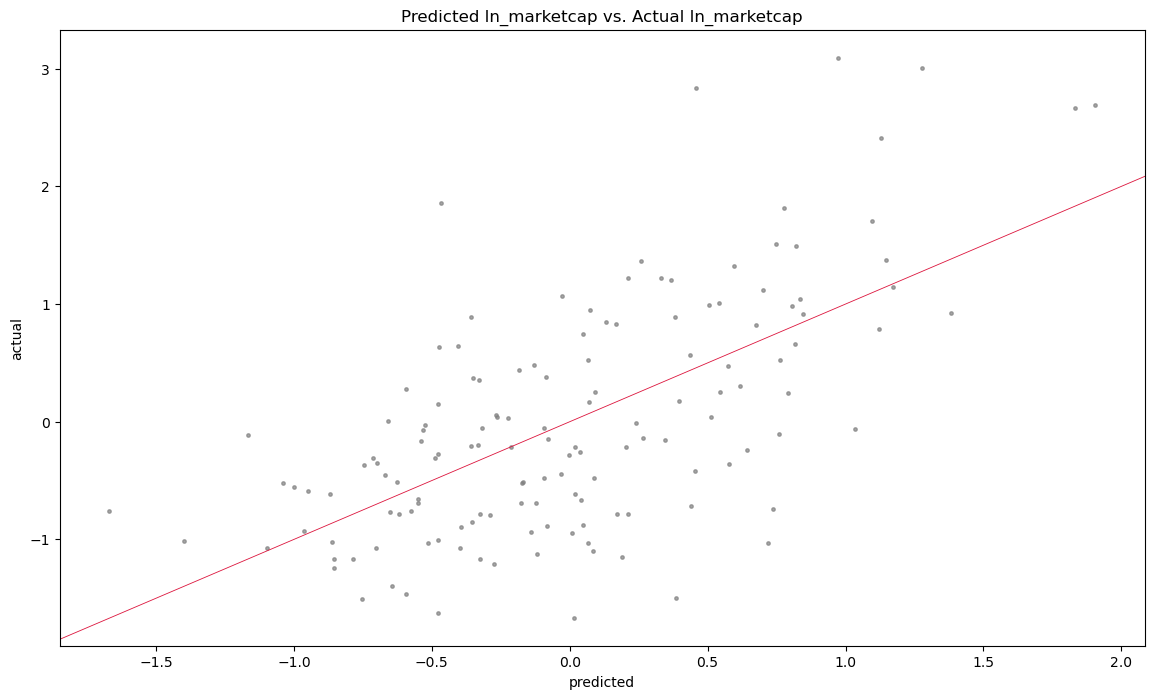

In [30]:
plot_model_residuals(EDA_df, ln_fulltime_coef, response='ln_marketcap', version='residuals')

Note that this scatter plot is a different visualization the predictions plotted against the residuals, where ther residual value is the distance of each datapoint from the 45 degree line. 

Hence, with all regression assumptions being fulfilled, the final regression model comes out to
$$\ln(\text{market cap}) = 0.3432*\text{ mean ratings} + 0.1989*\text{ governance risk score} + 0.5357*\ln(\text{ full time employees})$$